In [79]:
#Importing libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading dataset
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset['train'].to_pandas()

#Cleaning data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [80]:
df_IND=df[df['job_country']=='India'].copy().dropna(subset=['salary_year_avg'])

In [81]:
job_titles=df_IND['job_title_short'].value_counts().index[:6].to_list()


In [82]:
df_IND_top6=df_IND[df_IND['job_title_short'].isin(job_titles)]

In [83]:
job_order=df_IND_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

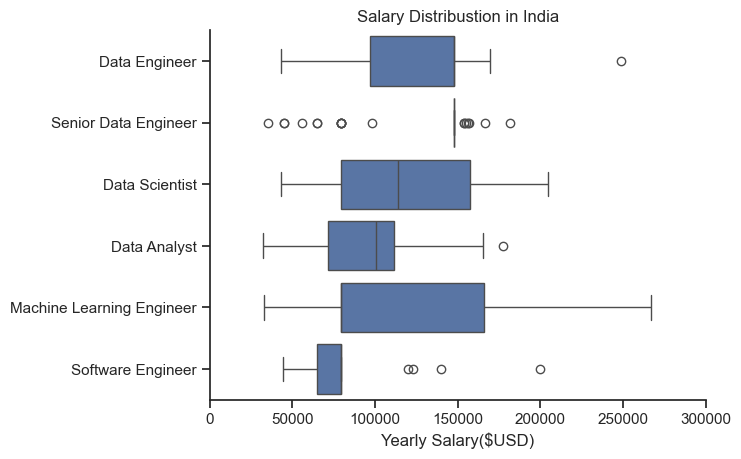

In [84]:
sns.set_theme(style='ticks')
sns.boxplot(data=df_IND_top6,x='salary_year_avg',y='job_title_short',order=job_order)
sns.despine()

plt.title('Salary Distribustion in India')
plt.xlabel('Yearly Salary($USD)')
plt.ylabel('')
plt.xlim(0,300000)
plt.show()

In [85]:
df_DA_IND=df_IND[df_IND['job_title_short']=='Data Analyst']
df_DA_IND=df_DA_IND.explode('job_skills')

In [86]:
df_top_skills=df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_top_skills.sort_values(by='count',ascending=False,inplace=True)
df_top_skills=df_top_skills.head(10)
df_top_skills.sort_values(by='median',ascending=False,inplace=True)

In [87]:
df_top_pay=df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_top_pay.sort_values(by='median',ascending=False,inplace=True)
df_top_pay=df_top_pay.head(10)

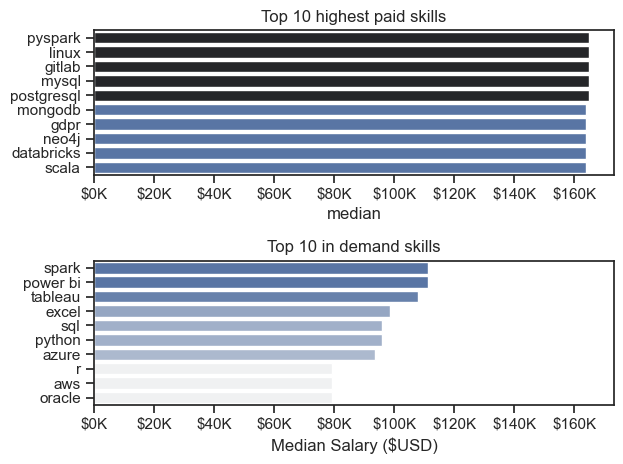

In [88]:
fig,ax=plt.subplots(2,1)

sns.set_theme(style='ticks')
# sns.despine()

sns.barplot(data=df_top_pay,x='median',y='job_skills',ax=ax[0],hue='median',palette='dark:b_r',legend=False)
ax[0].set_title('Top 10 highest paid skills')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${int(x/1000)}K'))
sns.barplot(data=df_top_skills,x='median',y='job_skills',ax=ax[1],hue='median',palette='light:b',legend=False)
ax[1].set_title('Top 10 in demand skills')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${int(x/1000)}K'))

fig.tight_layout()
plt.show()